# DATA-445 — Homework Assignment 1

**Instructions**

- This homework assignment is worth 94 points.
- Please submit a `.ipynb` file to Blackboard.
- Please strive for clarity and organization.
- **AI usage**:
  - AI use is strictly **prohibited** for conceptual exercises.
  - For applied (Python) exercises, you may use AI exclusively for **debugging**. Do not use AI to generate answers.
- **Due Date: September 11, 2026, by 11:59 PM.**

## Exercise 1

(4 points) What type of algorithm would you use to segment a company customers database into multiple groups?

I would use clustering to group customers into multiple groups.

## Exercise 2

(4 points) Would you frame the problem of spam detection as a supervised learning problem or an unsupervised learning problem? Explain.

I would frame the problem of spam detection as a supervised learning problem because there is a target, while unsupervised learning is meant to find patterns in data not for looking for a target.

## Exercise 3

(4 points) What is a test set, and why would you want to use it?

A test set is a split of the data you leave out of the models training and you use your model to make predictions against, it is meant to test your model against actual data not used in the training of the model.

## Exercise 4

(4 points) You are training a classification model with 100 variables/features that achieves 95% accuracy in the training dataset. However, when you run it in the test dataset, you only get 60% accuracy. Which of the following options are valid approached to solve this problem?

- (a) Reduce the number of input variables/features
- (b) Add extra variables/features
- (c) Implement cross-validation during the training process
- (d) Select another algorithm
- (e) (a) and (c)
- (f) (a) and (d)
- (g) (b) and (c)
- (h) (b) and (d)
- (i) None of the above


e

## Exercise 5

Consider the `Real_Estate.csv` data file posted on Blackboard (under the In-Class 3f assignment link). This file contains information related to 414 houses. The goal is to predict the house price of unit area. In **Python**, answer the following:

### (a) (3 points)

Using the pandas library, read the csv data file and create a data-frame called `house_price`.

In [8]:
import pandas as pd

house_price = pd.read_csv("Real_Estate.csv")

house_price.head()

,No,transaction_date,house_age,distance_to_the_nearest_MRT_station,number_of_convenience_stores,latitude,longitude,house_price_of_unit_area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


### (b) (3 points)

Drop the `No` and `transaction_date` columns.

In [10]:
house_price = house_price.drop(columns=["No","transaction_date"])
house_price.head()

,house_age,distance_to_the_nearest_MRT_station,number_of_convenience_stores,latitude,longitude,house_price_of_unit_area
0,32.0,84.87882,10,24.98298,121.54024,37.9
1,19.5,306.59470,9,24.98034,121.53951,42.2
2,13.3,561.98450,5,24.98746,121.54391,47.3
3,13.3,561.98450,5,24.98746,121.54391,54.8
4,5.0,390.56840,5,24.97937,121.54245,43.1


### (c) (4 points)

Split the data-frame into two data-frames: train (80%) and test (20%).

In [24]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(house_price, test_size=0.2, random_state=42)


### (d) (8 points)

Using the `house_price` data-frame, compute the correlation between each input variable and `house_price_of_unit_area`, and display the results as a heatmap. Which two variables are most correlated (in absolute value) with the target variable?

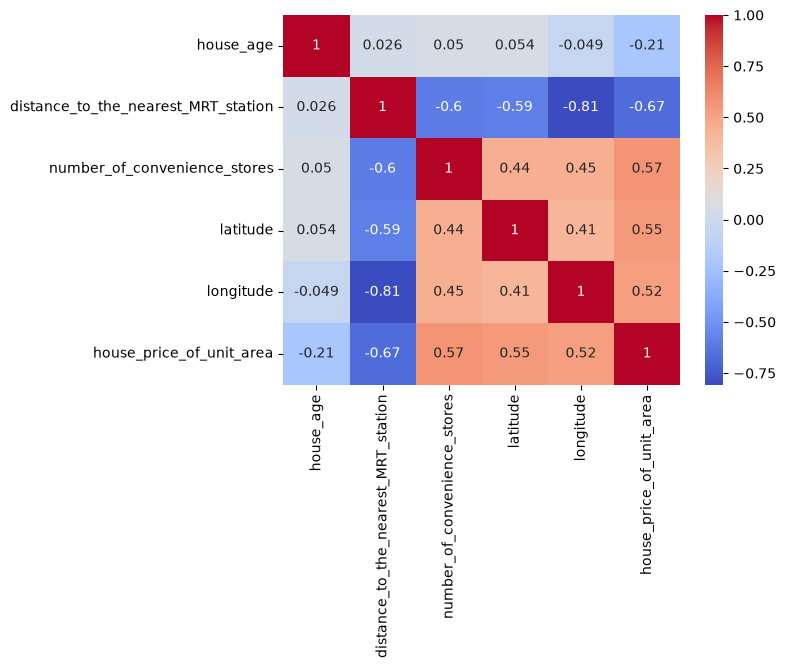

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = house_price.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()



the most correlated are distance to nearest mrt and number of convenience stores.

### (e) (10 points)

Using the train data-frame, build a linear regression model in which: `house_age`, `distance_to_the_nearest_MRT_station`, `number_of_convenience_stores`, `latitude`, and `longitude` are the input variables, and `house_price_of_unit_area` is the target variable. After the model is built, predict the house price of unit area of the houses in the test data-frame. Report the MSE.

In [27]:
from sklearn.linear_model import LinearRegression
import numpy as np

X_train= train[["house_age", "distance_to_the_nearest_MRT_station", "number_of_convenience_stores","latitude","longitude"]]
Y_train= train["house_price_of_unit_area"]

X_test= test[["house_age", "distance_to_the_nearest_MRT_station", "number_of_convenience_stores","latitude","longitude"]]
Y_test= test["house_price_of_unit_area"]

model = LinearRegression()
model.fit(X_train, Y_train)

predicted_price = model.predict(X_test)
predicted_price

mse = np.mean((Y_test - predicted_price) ** 2)
mse

np.float64(54.58094520086296)

I got the MSE as 54.58

### (f) (10 points)

Using the train data-frame, build a linear regression model in which: `house_age`, `number_of_convenience_stores`, `latitude`, and `longitude` are the input variables, and `house_price_of_unit_area` is the target variable. After the model is built, predict the house price of unit area of the houses in the test data-frame. Report the MSE.

In [29]:
X_train= house_price[["house_age", "number_of_convenience_stores","latitude","longitude"]]
Y_train= house_price["house_price_of_unit_area"]

X_test= test[["house_age", "number_of_convenience_stores","latitude","longitude"]]
Y_test= test["house_price_of_unit_area"]

model = LinearRegression()
model.fit(X_train, Y_train)

predicted_price = model.predict(X_test)
predicted_price

mse = np.mean((Y_test - predicted_price) ** 2)
mse

np.float64(57.50803779021282)

i got the MSE as 57.755

### (g) (5 points)

Using the results from parts (e) and (f), what model would you use? Explain.

I would use (e) because the MSE is smaller meaning the prediction is closer to the actual data.

### (h) (15 points)

Repeat steps (c) to (e) 100 times, and visualize the MSE of each of the models at each iteration. Which of the two model has better performance on the test datasets? Explain.

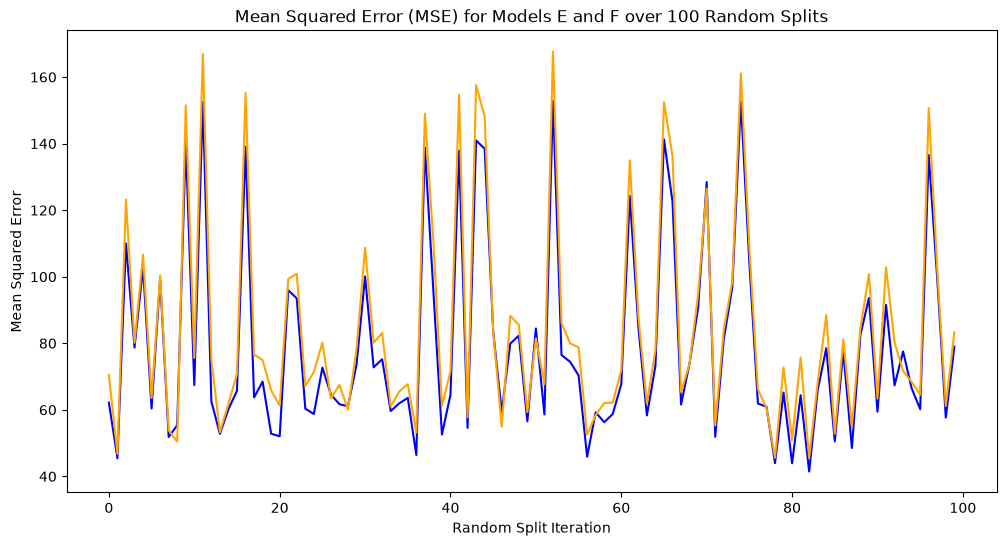

(np.float64(78.75395650514949), np.float64(84.58968755701282))

In [35]:
MSE_E = []
MSE_F = []
for i in range(100):
    train, test = train_test_split(house_price, test_size=0.2, random_state=i)
    
    X_train= train[["house_age", "distance_to_the_nearest_MRT_station", "number_of_convenience_stores","latitude","longitude"]]
    Y_train= train["house_price_of_unit_area"]

    X_test= test[["house_age", "distance_to_the_nearest_MRT_station", "number_of_convenience_stores","latitude","longitude"]]
    Y_test= test["house_price_of_unit_area"]

    model = LinearRegression()
    model.fit(X_train, Y_train)

    predicted_price = model.predict(X_test)

    mse = np.mean((Y_test - predicted_price) ** 2)
    
    MSE_E.append(mse)
    
    X_train= train[["house_age", "number_of_convenience_stores","latitude","longitude"]]
    Y_train= train["house_price_of_unit_area"]

    X_test= test[["house_age", "number_of_convenience_stores","latitude","longitude"]]
    Y_test= test["house_price_of_unit_area"]
    
    model = LinearRegression()
    model.fit(X_train, Y_train)
    
    predicted_price = model.predict(X_test)
    
    mse = np.mean((Y_test - predicted_price) ** 2)
    MSE_F.append(mse)
    
plt.figure(figsize=(12, 6))
plt.plot(MSE_E, label='Model E (with distance_to_the_nearest_MRT_station)', color='blue')
plt.plot(MSE_F, label='Model F (without distance_to_the_nearest_MRT_station)', color='orange')
plt.title('Mean Squared Error (MSE) for Models E and F over 100 Random Splits')
plt.xlabel('Random Split Iteration')
plt.ylabel('Mean Squared Error')
plt.show()
    
np.mean(MSE_E), np.mean(MSE_F)


    

i took the average mse of both models over 100 iterations and the one with distance to mrt station performed better because it had a smaller mse.

### (i) (8 points) 
Using scikit-learn's `cross_val_score`, perform 10-fold cross-validation on the full model from Exercise 5, part (d) (using the entire `house_price` data-frame). Report the average MSE across the 10 folds.

In [36]:
from sklearn.model_selection import cross_val_score

X = house_price[["house_age", "distance_to_the_nearest_MRT_station", "number_of_convenience_stores","latitude","longitude"]]
Y = house_price["house_price_of_unit_area"]

model = LinearRegression()

cv_scores = cross_val_score(model, X, Y, cv=10, scoring='neg_mean_squared_error')

np.mean(-cv_scores)

np.float64(81.01108645099069)

the average is 81.011

## Exercise 6

(6 points) Explain the bias-variance tradeoff, and describe how it relates to a model's ability to generalize to new/unseen data.

high bias is when the model is too simple while high variance is when the model is too sensitive to the changes in data. you dont want a model to be too simple because it wont be able to predict a model well and you dont want a model to be too sensitive because it will be too sensitive and overfit to data. you want a balance so the model can be generalized to new data.

## Exercise 7

(6 points) The "curse of dimensionality" refers to the difficulties that arise when working with data that has a very large number of features. Explain why having too many features can hurt the performance of a machine learning model, and describe one strategy to mitigate this problem.

having too many features can make variance increase, increasing the chances of overfitting. along with this the chances of multicollinearity can go up with too many features that relate to one another. A way to deal with this is cutting down on features with variable/feature selection.